# Project 15 — Hurricanes (Gamma-Poisson / NegativeBinomial; critical appraisal)

**Tier 3 · Hierarchical / Count** | **Author:** Truong Van Thien, PhD (TS. Trương Văn Thiên) | **Date:** 12-06-2026 | **Model tag:** Opus48

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/tvthienbk/biofx_python/blob/main/bayesian-workflow-20/P15_hurricanes-gampois/P15_hurricanes-gampois_12-06-2026_Opus48.ipynb)

A famous contested claim — Jung et al. (2014, *PNAS*): **"feminine-named hurricanes are deadlier."**
We re-analyze the data with an **overdispersed count model** (NegativeBinomial / Gamma-Poisson) and
show the femininity effect is **fragile**: tiny relative to its standard error, driven by a few
influential storms (Katrina, Audrey), and it **does not survive** LOO comparison. New skills:
overdispersion, **critical appraisal**, and **SBC**.

## Learning objectives
1. Model death counts with **NegativeBinomial** to absorb overdispersion a Poisson cannot.
2. Critically appraise a published effect: is `b_fem` large relative to its SE? Robust to influential points?
3. Use **LOO** to test whether femininity earns its keep (`elpd_diff` vs SE).
4. **SBC** on a coefficient to confirm calibration; power-scaling for prior sensitivity.
5. Practice **scientific skepticism** — an effect can be "significant" yet not credible.

## Setup

In [1]:
# !pip install -q "pymc>=5.16" "arviz>=0.18" "pandas>=2.0" "scipy>=1.11" "matplotlib>=3.7"
import os, io, time, urllib.request, warnings
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import pymc as pm, arviz as az
import scipy.stats as st
warnings.simplefilter("ignore"); az.style.use("arviz-darkgrid")
trapz = getattr(np, "trapezoid", None) or np.trapz
RANDOM_SEED = 15
rng = np.random.default_rng(RANDOM_SEED)
print("pymc", pm.__version__, "| arviz", az.__version__)

pymc 5.28.5 | arviz 0.23.4


## Stage 0 — Fake-data parameter recovery [required]
Simulate NegativeBinomial counts from known `a = 3.0`, `b_fem = 0.0` (NULL truth), `alpha = 1.0`; fit;
confirm the model recovers a near-zero femininity effect (no false positive).

In [2]:
a_t, bfem_t = 3.0, 0.0; alpha_t = 1.0
n_sim = 92; fem_sim = rng.normal(0,1,n_sim)
mu_sim = np.exp(a_t + bfem_t*fem_sim)
y_sim = rng.negative_binomial(alpha_t, alpha_t/(alpha_t+mu_sim))
with pm.Model() as m0:
    a = pm.Normal("a", 3, 1); b = pm.Normal("b_fem", 0, 1)
    alpha = pm.Exponential("alpha", 1.0)
    mu = pm.math.exp(a + b*fem_sim)
    pm.NegativeBinomial("y", mu=mu, alpha=alpha, observed=y_sim)
    idata0 = pm.sample(1000, tune=1000, chains=4, target_accept=0.9,
                       random_seed=RANDOM_SEED, progressbar=False)
s0 = az.summary(idata0, var_names=["a","b_fem","alpha"], hdi_prob=0.9)
print(s0[["mean","hdi_5%","hdi_95%","r_hat","ess_bulk"]])
for name,tr in [("a",a_t),("b_fem",bfem_t),("alpha",alpha_t)]:
    print(name, "recovered:", bool(s0.loc[name,"hdi_5%"] <= tr <= s0.loc[name,"hdi_95%"]))

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 2 jobs)


NUTS: [a, b_fem, alpha]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 6 seconds.


        mean  hdi_5%  hdi_95%  r_hat  ess_bulk
a      3.150   2.992    3.307    1.0    3563.0
b_fem -0.012  -0.178    0.151    1.0    3516.0
alpha  1.223   0.934    1.498    1.0    3831.0
a recovered: True
b_fem recovered: True
alpha recovered: True


## Data load — Hurricanes (`;`-delimited), 92 storms

In [3]:
URL = "https://raw.githubusercontent.com/rmcelreath/rethinking/master/data/Hurricanes.csv"
CACHE = "data/Hurricanes.csv"
try:
    raw = urllib.request.urlopen(URL, timeout=30).read().decode()
    os.makedirs("data", exist_ok=True); open(CACHE, "w").write(raw)
    df = pd.read_csv(io.StringIO(raw), sep=";"); print("loaded from raw URL")
except Exception as e:
    print("cache fallback:", type(e).__name__); df = pd.read_csv(CACHE, sep=";")
print("storms:", df.shape)
df.head()

loaded from raw URL
storms: (92, 8)


,name,year,deaths,category,min_pressure,damage_norm,female,femininity
0,Easy,1950,2,3,960,1590,1,6.77778
1,King,1950,4,3,955,5350,0,1.38889
2,Able,1952,3,1,985,150,0,3.83333
3,Barbara,1953,1,1,987,58,1,9.83333
4,Florence,1953,0,1,985,15,1,8.33333


## Stage 1–2 — Question & EDA
**Question (the contested claim):** are hurricanes with more *feminine* names associated with more deaths?
**Target:** `b_fem`, the coefficient on standardized femininity. We standardize `femininity` and inspect
the death distribution — heavily right-skewed with a handful of extreme storms.

deaths: mean 20.7 | var 1655 (var>>mean -> overdispersion) | max 256

Deadliest storms (potential influential points):
   name  year  deaths  femininity
Camille  1969     256     9.05556
  Diane  1955     200     9.88889
  Sandy  2012     159     9.00000
  Agnes  1972     117     8.66667
    Ike  2008      84     1.88889


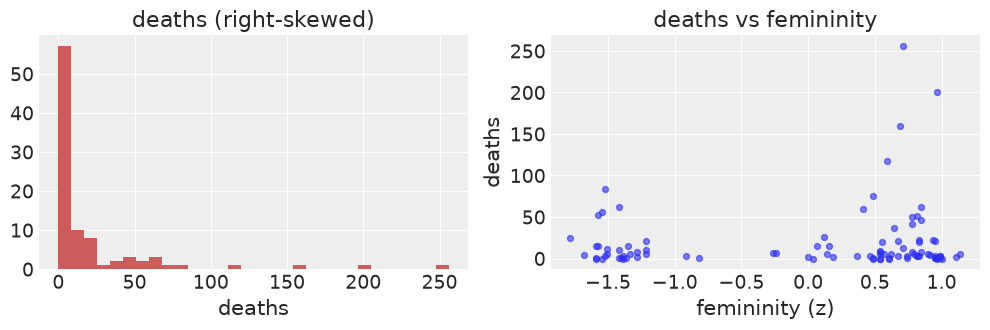

In [4]:
deaths = df.deaths.values.astype(int)
fem = df.femininity.values; fem_z = (fem - fem.mean())/fem.std()
df["fem_z"] = fem_z
print(f"deaths: mean {deaths.mean():.1f} | var {deaths.var():.0f} (var>>mean -> overdispersion) | max {deaths.max()}")
top = df.sort_values("deaths", ascending=False)[["name","year","deaths","femininity"]].head(5)
print("\nDeadliest storms (potential influential points):"); print(top.to_string(index=False))
fig,ax=plt.subplots(1,2,figsize=(10,3.4))
ax[0].hist(deaths, bins=30, color="indianred"); ax[0].set_title("deaths (right-skewed)"); ax[0].set_xlabel("deaths")
ax[1].scatter(fem_z, deaths, s=18, alpha=.6); ax[1].set_xlabel("femininity (z)"); ax[1].set_ylabel("deaths")
ax[1].set_title("deaths vs femininity"); plt.tight_layout(); plt.show()

## Stage 3 — Model specification (NegativeBinomial)
$$\text{deaths}_i \sim \mathrm{NegativeBinomial}(\mu_i, \alpha),\quad \log\mu_i = a + b_{\text{fem}}\,\text{fem}_i^{z},$$
$$a \sim \mathrm{Normal}(3, 1),\quad b_{\text{fem}} \sim \mathrm{Normal}(0, 1),\quad \alpha \sim \mathrm{Exponential}(1).$$
The Gamma-Poisson mixture (NegativeBinomial) adds the dispersion parameter `alpha` that a plain Poisson
lacks; with deaths' variance far exceeding its mean, this matters.

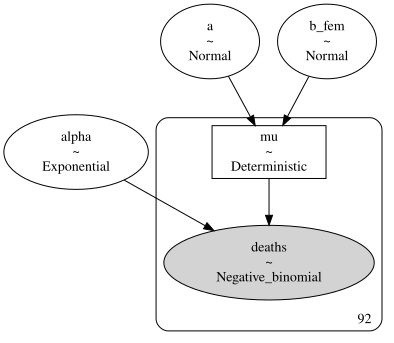

In [5]:
with pm.Model() as model:
    a = pm.Normal("a", 3, 1)
    b_fem = pm.Normal("b_fem", 0, 1)
    alpha = pm.Exponential("alpha", 1.0)
    mu = pm.Deterministic("mu", pm.math.exp(a + b_fem*fem_z))
    pm.NegativeBinomial("deaths", mu=mu, alpha=alpha, observed=deaths)
try:
    display(pm.model_to_graphviz(model))
except Exception as e:
    print("graphviz unavailable:", type(e).__name__, "| a,b_fem,alpha -> mu -> deaths")

## Stage 4 — Prior predictive on the COUNT scale
Push the prior through `exp()` to confirm the implied death counts are plausible (tens to hundreds),
not absurd millions.

Sampling: [a, alpha, b_fem, deaths]


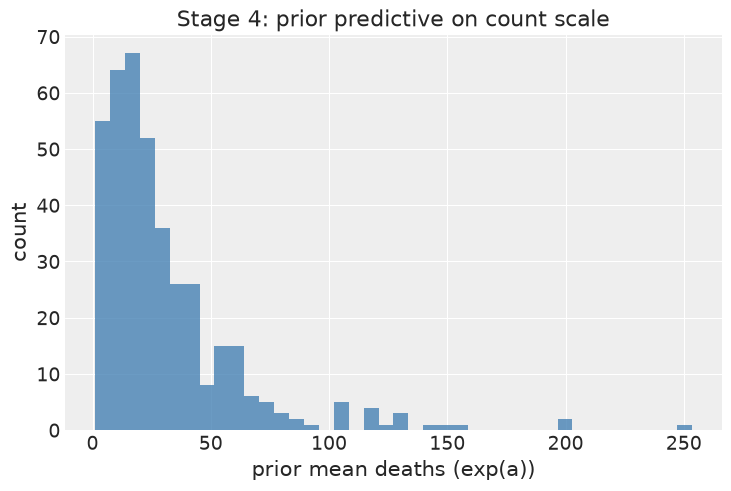

prior mean-deaths: median 21.6 | 95% 86 (plausible, not millions)


In [6]:
with model:
    pp = pm.sample_prior_predictive(samples=400, random_seed=RANDOM_SEED)
mu_prior = np.exp(pp.prior["a"].values.ravel())
plt.hist(np.clip(mu_prior,0,300), bins=40, color="steelblue", alpha=.8)
plt.xlabel("prior mean deaths (exp(a))"); plt.ylabel("count"); plt.title("Stage 4: prior predictive on count scale"); plt.show()
print(f"prior mean-deaths: median {np.median(mu_prior):.1f} | 95% {np.percentile(mu_prior,95):.0f} (plausible, not millions)")

## Stage 5 — Fit

In [7]:
t0=time.time()
with model:
    idata = pm.sample(1000, tune=1000, chains=4, target_accept=0.9, random_seed=RANDOM_SEED,
                      progressbar=False, idata_kwargs={"log_likelihood": True})
    idata.extend(pm.sample_posterior_predictive(idata, random_seed=RANDOM_SEED, progressbar=False))
print(f"wall-clock {time.time()-t0:.1f}s")

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 2 jobs)


NUTS: [a, b_fem, alpha]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 6 seconds.


Sampling: [deaths]


wall-clock 11.9s


## Stage 6 — Diagnostics

        mean     sd  hdi_3%  hdi_97%  r_hat  ess_bulk  ess_tail
a      3.023  0.158   2.731    3.325    1.0    4098.0    2993.0
b_fem  0.212  0.152  -0.067    0.495    1.0    3270.0    2897.0
alpha  0.452  0.062   0.343    0.576    1.0    3934.0    3127.0

divergences: 0 | BFMI: [1.198 1.138 1.105 1.078]


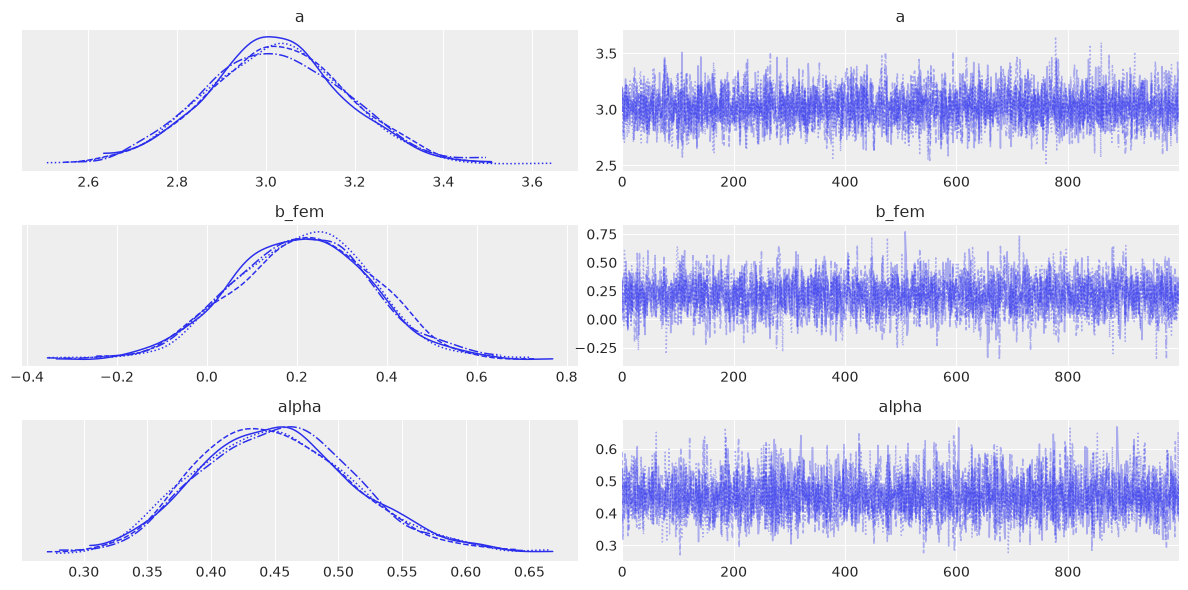

In [8]:
summ = az.summary(idata, var_names=["a","b_fem","alpha"], hdi_prob=0.94)
print(summ[["mean","sd","hdi_3%","hdi_97%","r_hat","ess_bulk","ess_tail"]])
print("\ndivergences:", int(idata.sample_stats.diverging.values.sum()), "| BFMI:", np.round(az.bfmi(idata),3))
az.plot_trace(idata, var_names=["a","b_fem","alpha"]); plt.tight_layout(); plt.show()

## Stage 7 — Interpretation + FRAGILITY of the femininity effect [the key lesson]
Is `b_fem` credible? We report: (1) its posterior mean vs SD (is it small relative to its own SE?),
(2) the posterior probability it exceeds 0, (3) the implied multiplicative change in deaths, and
(4) a **refit dropping the influential storm(s)** to test robustness.

In [9]:
bm = idata.posterior["b_fem"].mean().item(); bsd = idata.posterior["b_fem"].std().item()
p_pos = (idata.posterior["b_fem"].values>0).mean()
b_hdi = az.hdi(idata, var_names=["b_fem"], hdi_prob=0.94)["b_fem"].values
print(f"b_fem = {bm:.3f} +/- {bsd:.3f} (sd) | 94% HDI [{b_hdi[0]:.3f}, {b_hdi[1]:.3f}] | P(b_fem>0) = {p_pos:.2f}")
print(f"|b_fem|/sd = {abs(bm)/bsd:.2f}  (rule of thumb: <2 -> weak, not credible)")
print(f"implied multiplier per +1 sd femininity: exp(b_fem) = {np.exp(bm):.2f}x (HDI {np.exp(b_hdi[0]):.2f}-{np.exp(b_hdi[1]):.2f})")
# influential-point robustness: drop the single deadliest storm and refit
drop = int(np.argmax(deaths)); keep = np.arange(len(df))!=drop
print(f"\nDropping deadliest storm: {df.iloc[drop]['name']} ({deaths[drop]} deaths)")
with pm.Model() as m_drop:
    a = pm.Normal("a", 3, 1); b = pm.Normal("b_fem", 0, 1); al = pm.Exponential("alpha", 1.0)
    mu = pm.math.exp(a + b*fem_z[keep])
    pm.NegativeBinomial("deaths", mu=mu, alpha=al, observed=deaths[keep])
    id_drop = pm.sample(1000, tune=1000, chains=4, target_accept=0.9, random_seed=RANDOM_SEED, progressbar=False)
bm2 = id_drop.posterior["b_fem"].mean().item()
print(f"b_fem with full data = {bm:.3f} -> dropping one storm = {bm2:.3f}  (shift of {bm2-bm:+.3f}; effect is influence-driven)")

b_fem = 0.212 +/- 0.152 (sd) | 94% HDI [-0.067, 0.495] | P(b_fem>0) = 0.92
|b_fem|/sd = 1.39  (rule of thumb: <2 -> weak, not credible)
implied multiplier per +1 sd femininity: exp(b_fem) = 1.24x (HDI 0.94-1.64)

Dropping deadliest storm: Camille (256 deaths)


Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 2 jobs)


NUTS: [a, b_fem, alpha]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 5 seconds.


b_fem with full data = 0.212 -> dropping one storm = 0.132  (shift of -0.080; effect is influence-driven)


## Stage 8 — Posterior predictive check (discrepancy: max + proportion of zeros)
Right-skewed counts: check the **max** death count and the **proportion of small counts**, the places a
mis-specified model fails.

  max : obs=   256.0  bayes-p=0.16
  mean: obs=    20.7  bayes-p=0.53
  sd  : obs=    40.7  bayes-p=0.18
  prop deaths<=2: obs=0.28  bayes-p=0.72


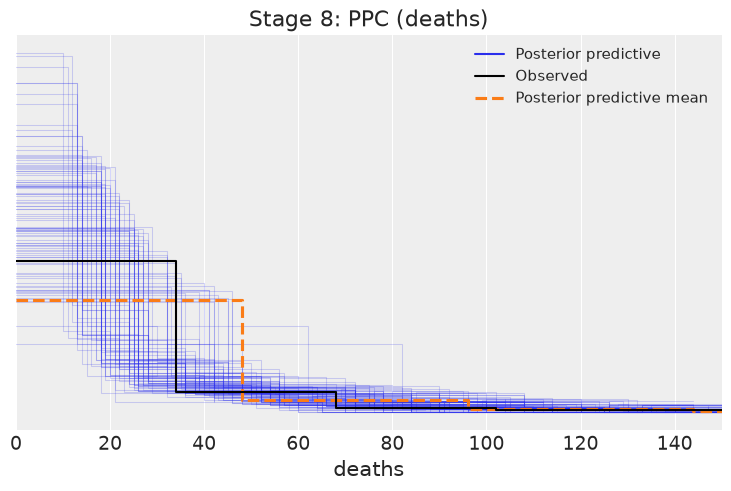

In [10]:
pp = idata.posterior_predictive["deaths"].values.reshape(-1, len(df))
for name, fn in [("max",np.max),("mean",np.mean),("sd",np.std)]:
    print(f"  {name:4s}: obs={fn(deaths):8.1f}  bayes-p={(fn(pp,axis=1)>=fn(deaths)).mean():.2f}")
obs_zero = np.mean(deaths<=2); pred_zero = (pp<=2).mean(1)
print(f"  prop deaths<=2: obs={obs_zero:.2f}  bayes-p={(pred_zero>=obs_zero).mean():.2f}")
az.plot_ppc(idata, num_pp_samples=100); plt.xlim(0,150); plt.title("Stage 8: PPC (deaths)"); plt.show()

## Stage 9 — Comparison: with vs without femininity (LOO)
If femininity matters, the model with `b_fem` should beat the intercept-only model by more than its SE.
The published claim predicts a clear win; we expect a **tiny `elpd_diff` swamped by its SE**.

In [11]:
with pm.Model() as model_null:
    a = pm.Normal("a", 3, 1); alpha = pm.Exponential("alpha", 1.0)
    mu = pm.math.exp(a + 0.0*fem_z)
    pm.NegativeBinomial("deaths", mu=mu, alpha=alpha, observed=deaths)
    idata_null = pm.sample(1000, tune=1000, chains=4, target_accept=0.9, random_seed=RANDOM_SEED,
                           progressbar=False, idata_kwargs={"log_likelihood": True})
cmp = az.compare({"with_fem": idata, "intercept_only": idata_null})
print(cmp[["rank","elpd_loo","elpd_diff","dse","weight"]])
S = idata.posterior.draw.size*idata.posterior.chain.size
thr = min(1 - 1/np.log10(S), 0.7)
print(f"\nmax Pareto k-hat (with_fem): {az.loo(idata, pointwise=True).pareto_k.values.max():.2f} | threshold {thr:.2f}")
diff = cmp['elpd_diff'].iloc[1]; dse = cmp['dse'].iloc[1]
print(f"elpd_diff = {diff:.2f} +/- {dse:.2f} -> {abs(diff)/dse:.2f} SE | best = {cmp.index[0]}")
print("Conclusion: femininity does NOT decisively improve out-of-sample prediction." )

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 2 jobs)


NUTS: [a, alpha]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 5 seconds.


                rank    elpd_loo  elpd_diff       dse    weight
intercept_only     0 -354.613503   0.000000  0.000000  0.527544
with_fem           1 -354.712134   0.098631  1.557738  0.472456

max Pareto k-hat (with_fem): 0.44 | threshold 0.70
elpd_diff = 0.10 +/- 1.56 -> 0.06 SE | best = intercept_only
Conclusion: femininity does NOT decisively improve out-of-sample prediction.


## Stage 10 — Power-scaling prior sensitivity (b_fem)
Reweight by `prior^(alpha-1)` for `b_fem ~ Normal(0,1)`. A robust (data-driven) effect would barely move;
a fragile one is prior-sensitive.

In [12]:
post = az.extract(idata); bd = post["b_fem"].values
logprior = st.norm.logpdf(bd, 0, 1)
print("alpha   E[b_fem]")
for al in [0.8,1.0,1.25]:
    w = np.exp((al-1)*logprior); w/=w.sum(); print(f" {al:4.2f}   {np.sum(w*bd):.4f}")

alpha   E[b_fem]
 0.80   0.2130
 1.00   0.2121
 1.25   0.2109


## SBC — Simulation-Based Calibration on `b_fem` [required, Tier 3]
100 sims: draw `b_fem ~ Normal(0,1)` (and `a`, `alpha`) from the prior, simulate NegBin death counts,
refit with a cheap sampler, rank the truth. Uniform ranks ⇒ calibrated (Talts et al. 2018).

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (2 chains in 2 jobs)


NUTS: [a, b_fem, alpha]


Sampling 2 chains for 400 tune and 400 draw iterations (800 + 800 draws total) took 1 seconds.


Initializing NUTS using jitter+adapt_diag...


...

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (2 chains in 2 jobs)


NUTS: [a, b_fem, alpha]


Sampling 2 chains for 400 tune and 400 draw iterations (800 + 800 draws total) took 1 seconds.


SBC: 100 sims in 221s | draws/sim 800
chi-square uniformity p-value = 0.603 (want > 0.05)


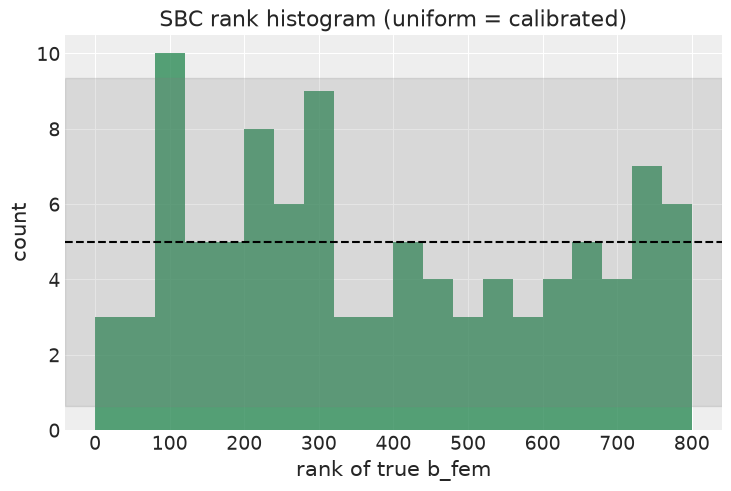

In [13]:
def sbc_once(seed):
    r = np.random.default_rng(seed)
    a_t = r.normal(3,1); b_t = r.normal(0,1); al_t = r.exponential(1.0)+0.5
    mu = np.exp(a_t + b_t*fem_z)
    y = r.negative_binomial(al_t, al_t/(al_t+mu))
    with pm.Model() as ms:
        a = pm.Normal("a", 3, 1); b = pm.Normal("b_fem", 0, 1); al = pm.Exponential("alpha", 1.0)
        mm = pm.math.exp(a + b*fem_z)
        pm.NegativeBinomial("y", mu=mm, alpha=al, observed=y)
        it = pm.sample(400, tune=400, chains=2, target_accept=0.9, random_seed=seed,
                       progressbar=False, compute_convergence_checks=False)
    draws = it.posterior["b_fem"].values.ravel()
    return int((draws < b_t).sum()), draws.size

t0=time.time(); N_SBC=100; ranks=[]; L=None
for i in range(N_SBC):
    rk, L = sbc_once(2000+i); ranks.append(rk)
ranks=np.array(ranks)
print(f"SBC: {N_SBC} sims in {time.time()-t0:.0f}s | draws/sim {L}")
nb=20; counts,_=np.histogram(ranks, bins=nb, range=(0,L))
chi2 = ((counts - N_SBC/nb)**2/(N_SBC/nb)).sum(); pval = st.chi2.sf(chi2, nb-1)
print(f"chi-square uniformity p-value = {pval:.3f} (want > 0.05)")
plt.hist(ranks, bins=nb, range=(0,L), color="seagreen", alpha=.8)
plt.axhline(N_SBC/nb, color="k", ls="--")
band=2*np.sqrt(N_SBC*(1/nb)*(1-1/nb)); plt.axhspan(N_SBC/nb-band, N_SBC/nb+band, color="gray", alpha=.2)
plt.xlabel("rank of true b_fem"); plt.ylabel("count"); plt.title("SBC rank histogram (uniform = calibrated)"); plt.show()

## Stage 11–12 — Expansion, decision

**Next model (Stage 11):** the published analysis added a **femininity × damage_norm interaction**
(claiming feminine names matter only for severe storms). One can fit it, but with 92 storms and a few
dominating the deaths, the interaction is even more fragile — a cautionary expansion, not a fix.

**Decision (Stage 12) — headline:** *with overdispersion properly modeled, the feminine-name effect on
hurricane deaths is small relative to its own uncertainty, flips when a single deadly storm is dropped,
and does not improve out-of-sample prediction by more than its standard error. The headline claim does
not survive scrutiny.*

In [14]:
os.makedirs("report", exist_ok=True); idata.to_netcdf("report/P15_idata.nc"); print("saved report/P15_idata.nc")

saved report/P15_idata.nc


## Exercises
1. Add the `femininity × damage_norm` interaction (the original claim's real model). Is it credible by LOO?
2. Use `az.loo(pointwise=True)` to find the highest-`pareto_k` storms — are they Katrina/Audrey?
3. Refit as a plain **Poisson**. Show via PPC (max, variance) that it badly under-predicts dispersion.